In [1]:
# %pip install -U git+https://github.com/szagoruyko/pytorchviz.git@master
# %pip install thop
# %pip install torchinfo
# %pip install -U segmentation-models-pytorch

import torch
from torch import nn

from torchviz import make_dot, make_dot_from_trace
from thop import profile, clever_format
from torchinfo import summary
import numpy as np

In [2]:
from pynas.core.generic_unet import GenericUNetNetwork

# MYRIAD MODEL 
parsed_layers = [{'layer_type': 'Dropout', 'dropout_rate': 0.16},
 {'layer_type': 'AvgPool'},
 {'layer_type': 'Dropout', 'dropout_rate': 0.48},
 {'layer_type': 'AvgPool'},
 {'layer_type': 'MBConv', 'expansion_factor': '4', 'activation': 'GELU'},
 {'layer_type': 'AvgPool'}]


model_myriad = GenericUNetNetwork(parsed_layers,
        input_channels=7, 
        input_height=256, 
        input_width=256, 
        num_classes=4,
        encoder_only=False,
)

# ORIN MODEL 
parsed_layers = [{'layer_type': 'Dropout', 'dropout_rate': 0.15},
{'layer_type': 'AvgPool'},
{'layer_type': 'ConvSE',
'out_channels_coefficient': 4,
'kernel_size': '3',
'stride': '1',
'padding': '1',
'activation': 'ReLU'},
{'layer_type': 'AvgPool'},
{'layer_type': 'MBConvNoRes', 'expansion_factor': '5', 'activation': 'ReLU'},
{'layer_type': 'AvgPool'}]


model_orin = GenericUNetNetwork(parsed_layers,
        input_channels=7, 
        input_height=256, 
        input_width=256, 
        num_classes=4,
        encoder_only=False,
)

# =================================================================================================
import segmentation_models_pytorch as smp

resnet_model = smp.Unet(
    encoder_name="resnet18",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=7,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=4,                      # model output channels (number of classes in your dataset)
)

eff_model = smp.Unet(
    encoder_name="efficientnet-b0",     # changed from resnet18 to efficientnet-b0
    encoder_weights="imagenet",         # use `imagenet` pre-trained weights for encoder initialization
    in_channels=7,                      # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=4,                          # model output channels (number of classes in your dataset)
)

mobil_model = smp.Unet(
    encoder_name="mobileone_s0",     # changed from resnet18 to efficientnet-b0
    encoder_weights="imagenet",         # use `imagenet` pre-trained weights for encoder initialization
    in_channels=7,                      # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=4,                          # model output channels (number of classes in your dataset)
)




/Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/.venv/lib/python3.9/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
for m in [model_myriad, model_orin, resnet_model, eff_model, mobil_model]:
    m.eval()

# model.eval()

def print_model_info(model: nn.Module, input_tensor: torch.Tensor) -> None:
    """
    Print comprehensive model information including layers, parameters, MACs, and GFLOPs.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_tensor (torch.Tensor): Sample input tensor for the model
    """
    print('=' * 80)
    print('MODEL COMPREHENSIVE ANALYSIS')
    print('=' * 80)
    
    # Basic model info
    print(f'\nMODEL TYPE: {type(model).__name__}')
    print(f'INPUT SHAPE: {list(input_tensor.shape)}')
    
    # Model architecture summary
    print('\n' + '='*50)
    print('MODEL ARCHITECTURE SUMMARY')
    print('='*50)
    try:
        model_summary = summary(model, input_size=input_tensor.shape[1:], 
                              batch_dim=0, device='cpu', verbose=0)
        print(model_summary)
    except Exception as e:
        print(f'Could not generate torchinfo summary: {e}')
    
    # Parameter analysis
    print('\n' + '='*50)
    print('PARAMETER ANALYSIS')
    print('='*50)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params
    
    print(f'Total Parameters: {total_params:,}')
    print(f'Trainable Parameters: {trainable_params:,}')
    print(f'Non-trainable Parameters: {non_trainable_params:,}')
    
    # Model size calculation
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    model_size_mb = (param_size + buffer_size) / 1024 / 1024
    
    print(f'Model Size: {model_size_mb:.2f} MB')
    
    # MACs and GFLOPs analysis using thop
    print('\n' + '='*50)
    print('COMPUTATIONAL COMPLEXITY')
    print('='*50)
    
    try:
        # Clone model and input for profiling
        model_copy = model
        input_copy = input_tensor.clone()
        
        macs, params = profile(model_copy, inputs=(input_copy,), verbose=False)
        macs_formatted, params_formatted = clever_format([macs, params], "%.3f")
        
        # Convert MACs to GFLOPs (1 GFLOP = 1e9 FLOPs, 1 MAC ≈ 2 FLOPs for most operations)
        gflops = macs * 2 / 1e9
        
        print(f'MACs (Multiply-Accumulate Operations): {macs_formatted}')
        print(f'Estimated GFLOPs: {gflops:.3f}')
        print(f'Parameters (thop): {params_formatted}')
        
    except Exception as e:
        print(f'Could not calculate MACs/GFLOPs: {e}')
    
    # Memory usage estimation
    print('\n' + '='*50)
    print('MEMORY USAGE ESTIMATION')
    print('='*50)
    
    # Input memory
    input_memory = input_tensor.numel() * input_tensor.element_size()
    
    # Output memory (approximate)
    with torch.no_grad():
        try:
            output = model(input_tensor)
            if isinstance(output, (list, tuple)):
                output_memory = sum(o.numel() * o.element_size() for o in output)
                output_shapes = [list(o.shape) for o in output]
            else:
                output_memory = output.numel() * output.element_size()
                output_shapes = list(output.shape)
            
            print(f'Input Memory: {input_memory / 1024 / 1024:.2f} MB')
            print(f'Output Memory: {output_memory / 1024 / 1024:.2f} MB')
            print(f'Output Shape(s): {output_shapes}')
            
        except Exception as e:
            print(f'Could not estimate output memory: {e}')
    
    # Layer-by-layer breakdown
    print('\n' + '='*50)
    print('LAYER BREAKDOWN')
    print('='*50)
    
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # Only leaf modules
            num_params = sum(p.numel() for p in module.parameters())
            if num_params > 0:
                print(f'{name:<40} | {type(module).__name__:<20} | Params: {num_params:>8,}')
    
    print('\n' + '='*80)
    print('ANALYSIS COMPLETE')
    print('='*80)

In [4]:
x = torch.randn(1, 7, 256, 256)
# Print comprehensive model information
print_model_info(mobil_model, x)



# print('\n\nGENERATING COMPUTATION GRAPH...')
# Generate computation graph
# make_dot(model(x), params=dict(model.named_parameters()), show_attrs=True, show_saved=True)

MODEL COMPREHENSIVE ANALYSIS

MODEL TYPE: Unet
INPUT SHAPE: [1, 7, 256, 256]

MODEL ARCHITECTURE SUMMARY
Layer (type:depth-idx)                             Output Shape              Param #
Unet                                               [1, 4, 256, 256]          --
├─MobileOne: 1-1                                   [1, 7, 256, 256]          --
│    └─MobileOneBlock: 2-1                         [1, 48, 128, 128]         --
│    │    └─Sequential: 3-1                        [1, 48, 128, 128]         432
│    │    └─ModuleList: 3-2                        --                        3,120
│    │    └─Identity: 3-3                          [1, 48, 128, 128]         --
│    │    └─ReLU: 3-4                              [1, 48, 128, 128]         --
│    └─Sequential: 2-2                             [1, 48, 64, 64]           --
│    │    └─MobileOneBlock: 3-5                    [1, 48, 64, 64]           2,256
│    │    └─MobileOneBlock: 3-6                    [1, 48, 64, 64]           9,696


In [5]:
def calculate_model_macs_detailed(model: nn.Module, input_tensor: torch.Tensor) -> dict:
    """
    Calculate MACs and GFLOPs using multiple methods for comparison.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_tensor (torch.Tensor): Sample input tensor for the model
        
    Returns:
        dict: Dictionary containing MAC/GFLOP calculations from different methods
    """
    results = {}
    
    # Method 1: Using thop
    try:
        from thop import profile, clever_format
        model_copy = model
        input_copy = input_tensor.clone()
        
        macs, params = profile(model_copy, inputs=(input_copy,), verbose=False)
        macs_formatted, params_formatted = clever_format([macs, params], "%.3f")
        
        # Convert MACs to GFLOPs (1 MAC ≈ 2 FLOPs for most operations)
        gflops = macs * 2 / 1e9
        
        results['thop'] = {
            'macs': macs,
            'macs_formatted': macs_formatted,
            'gflops': gflops,
            'params': params,
            'params_formatted': params_formatted
        }
        
    except Exception as e:
        results['thop'] = {'error': str(e)}
    
    # Method 2: Using torchinfo (FLOPs estimation)
    try:
        from torchinfo import summary
        model_summary = summary(model, input_size=input_tensor.shape[1:], 
                              batch_dim=0, device='cpu', verbose=0)
        
        # Extract multiply-adds from torchinfo if available
        if hasattr(model_summary, 'total_mult_adds'):
            mult_adds = model_summary.total_mult_adds
            gflops_torchinfo = mult_adds / 1e9
            
            results['torchinfo'] = {
                'mult_adds': mult_adds,
                'gflops': gflops_torchinfo,
                'total_params': model_summary.total_params,
                'trainable_params': model_summary.trainable_params
            }
        else:
            results['torchinfo'] = {'info': 'Multiply-adds not available in torchinfo summary'}
            
    except Exception as e:
        results['torchinfo'] = {'error': str(e)}
    
    # Method 3: Manual calculation for common layer types
    try:
        manual_macs = 0
        
        def calculate_conv2d_macs(module, input_shape, output_shape):
            """Calculate MACs for Conv2d layer"""
            if len(input_shape) == 4:  # [B, C, H, W]
                _, _, out_h, out_w = output_shape
                _, in_c, _, _ = input_shape
                kernel_h, kernel_w = module.kernel_size
                macs = out_h * out_w * in_c * kernel_h * kernel_w
                if module.groups > 1:
                    macs = macs // module.groups
                return macs
            return 0
        
        def calculate_linear_macs(module, input_shape):
            """Calculate MACs for Linear layer"""
            return module.in_features * module.out_features
        
        # This is a simplified manual calculation - would need hooks for full accuracy
        for name, module in model.named_modules():
            if isinstance(module, nn.Conv2d):
                # Simplified estimation - would need actual shapes from forward pass
                if hasattr(module, 'weight'):
                    kernel_macs = np.prod(module.kernel_size) * module.in_channels * module.out_channels
                    # Rough estimation based on input size and stride/padding
                    out_size_estimate = (256 // (module.stride[0] if module.stride else 1)) ** 2
                    manual_macs += kernel_macs * out_size_estimate
                    
            elif isinstance(module, nn.Linear):
                if hasattr(module, 'weight'):
                    manual_macs += module.in_features * module.out_features
        
        manual_gflops = manual_macs * 2 / 1e9
        
        results['manual_estimate'] = {
            'macs': manual_macs,
            'gflops': manual_gflops,
            'note': 'Rough estimation - may not be accurate for complex architectures'
        }
        
    except Exception as e:
        results['manual_estimate'] = {'error': str(e)}
    
    return results

def print_macs_comparison(model: nn.Module, input_tensor: torch.Tensor) -> None:
    """
    Print a comparison of MAC/GFLOP calculations from different methods.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_tensor (torch.Tensor): Sample input tensor for the model
    """
    print('=' * 80)
    print('MAC/GFLOPS CALCULATION COMPARISON')
    print('=' * 80)
    
    results = calculate_model_macs_detailed(model, input_tensor)
    
    for method_name, method_results in results.items():
        print(f'\n--- {method_name.upper()} METHOD ---')
        
        if 'error' in method_results:
            print(f'❌ Error: {method_results["error"]}')
            continue
            
        if 'macs' in method_results:
            macs = method_results['macs']
            if isinstance(macs, (int, float)):
                print(f'MACs: {macs:,.0f} ({macs/1e6:.2f}M)')
            else:
                print(f'MACs: {macs}')
                
        if 'gflops' in method_results:
            gflops = method_results['gflops']
            if isinstance(gflops, (int, float)):
                print(f'GFLOPs: {gflops:.3f}')
            else:
                print(f'GFLOPs: {gflops}')
                
        if 'params' in method_results:
            params = method_results['params']
            if isinstance(params, (int, float)):
                print(f'Parameters: {params:,.0f} ({params/1e6:.2f}M)')
                
        if 'note' in method_results:
            print(f'Note: {method_results["note"]}')
            
        # Print other relevant info
        for key, value in method_results.items():
            if key not in ['macs', 'gflops', 'params', 'error', 'note']:
                if isinstance(value, (int, float)) and value > 1000:
                    print(f'{key}: {value:,.0f}')
                else:
                    print(f'{key}: {value}')
    
    print('\n' + '='*80)

def get_flops_per_layer(model: nn.Module, input_tensor: torch.Tensor) -> dict:
    """
    Get FLOPs breakdown per layer using hooks.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_tensor (torch.Tensor): Sample input tensor for the model
        
    Returns:
        dict: FLOPs per layer
    """
    flops_dict = {}
    
    def conv2d_flop_count(module, input_shape, output_shape):
        """Calculate FLOPs for Conv2d"""
        batch_size = input_shape[0]
        output_dims = output_shape[2:]
        kernel_dims = module.kernel_size
        in_channels = module.in_channels
        out_channels = module.out_channels
        groups = module.groups
        
        filters_per_channel = out_channels // groups
        conv_per_position_flops = int(np.prod(kernel_dims)) * in_channels // groups
        
        active_elements_count = batch_size * int(np.prod(output_dims))
        overall_conv_flops = conv_per_position_flops * active_elements_count * filters_per_channel
        
        bias_flops = 0
        if module.bias is not None:
            bias_flops = out_channels * active_elements_count
            
        return overall_conv_flops + bias_flops
    
    def linear_flop_count(module, input_shape, output_shape):
        """Calculate FLOPs for Linear"""
        return module.in_features * module.out_features
    
    def create_flop_hook(name):
        def hook_fn(module, input, output):
            input_shape = input[0].shape if isinstance(input, tuple) else input.shape
            output_shape = output.shape if not isinstance(output, tuple) else output[0].shape
            
            flops = 0
            if isinstance(module, nn.Conv2d):
                flops = conv2d_flop_count(module, input_shape, output_shape)
            elif isinstance(module, nn.Linear):
                flops = linear_flop_count(module, input_shape, output_shape)
            
            flops_dict[name] = flops
        return hook_fn
    
    # Register hooks
    hooks = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            hook = module.register_forward_hook(create_flop_hook(name))
            hooks.append(hook)
    
    # Forward pass
    model.eval()
    with torch.no_grad():
        _ = model(input_tensor)
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    return flops_dict

In [6]:
model = resnet_model




# Test the enhanced MAC/GFLOPS calculations
print("🔍 ENHANCED MAC/GFLOPS ANALYSIS")
print("=" * 80)

# Run the comparison of different methods
print_macs_comparison(model, x)

print("\n\n🧩 LAYER-WISE FLOPS BREAKDOWN")
print("=" * 80)

# Get FLOPs breakdown per layer
layer_flops = get_flops_per_layer(model, x)

if layer_flops:
    total_flops = sum(layer_flops.values())
    print(f"Total FLOPs from layer analysis: {total_flops:,.0f} ({total_flops/1e9:.3f} GFLOPs)")
    print("\nTop layers by FLOPs:")
    
    # Sort layers by FLOPs
    sorted_layers = sorted(layer_flops.items(), key=lambda x: x[1], reverse=True)
    
    for name, flops in sorted_layers[:10]:  # Show top 10
        if flops > 0:
            print(f"  {name:<40}: {flops:>12,.0f} ({flops/1e6:.2f}M) FLOPs")
    
    print(f"\n... and {len(sorted_layers)-10} more layers" if len(sorted_layers) > 10 else "")
else:
    print("No layer-wise FLOP data available")

print("\n" + "=" * 80)

🔍 ENHANCED MAC/GFLOPS ANALYSIS
MAC/GFLOPS CALCULATION COMPARISON

--- THOP METHOD ---
MACs: 5,661,130,752 (5661.13M)
GFLOPs: 11.322
Parameters: 14,341,188 (14.34M)
macs_formatted: 5.661G
params_formatted: 14.341M

--- TORCHINFO METHOD ---
GFLOPs: 5.632
mult_adds: 5,632,175,424
total_params: 14,341,188
trainable_params: 14,341,188

--- MANUAL_ESTIMATE METHOD ---
MACs: 853468512256
GFLOPs: 1706.937
Note: Rough estimation - may not be accurate for complex architectures



🧩 LAYER-WISE FLOPS BREAKDOWN
Total FLOPs from layer analysis: 5,632,163,840 (5.632 GFLOPs)

Top layers by FLOPs:
  decoder.blocks.3.conv1.0                :  603,979,776 (603.98M) FLOPs
  decoder.blocks.0.conv1.0                :  452,984,832 (452.98M) FLOPs
  decoder.blocks.1.conv1.0                :  452,984,832 (452.98M) FLOPs
  decoder.blocks.2.conv1.0                :  452,984,832 (452.98M) FLOPs
  encoder.conv1                           :  359,661,568 (359.66M) FLOPs
  decoder.blocks.4.conv1.0                :  301

In [7]:
def calculate_receptive_field(model: nn.Module, input_size: tuple = (256, 256)) -> dict:
    """
    Calculate the receptive field of a CNN model.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_size (tuple): Input spatial dimensions (H, W)
        
    Returns:
        dict: Dictionary containing receptive field information
    """
    
    def get_layer_info(module):
        """Extract layer parameters for receptive field calculation"""
        if isinstance(module, nn.Conv2d):
            kernel_size = module.kernel_size[0] if isinstance(module.kernel_size, tuple) else module.kernel_size
            stride = module.stride[0] if isinstance(module.stride, tuple) else module.stride
            padding = module.padding[0] if isinstance(module.padding, tuple) else module.padding
            dilation = module.dilation[0] if isinstance(module.dilation, tuple) else module.dilation
            return {
                'type': 'conv2d',
                'kernel_size': kernel_size,
                'stride': stride,
                'padding': padding,
                'dilation': dilation
            }
        elif isinstance(module, (nn.MaxPool2d, nn.AvgPool2d)):
            kernel_size = module.kernel_size if isinstance(module.kernel_size, int) else module.kernel_size[0]
            stride = module.stride if module.stride is not None else kernel_size
            if isinstance(stride, (list, tuple)):
                stride = stride[0]
            padding = getattr(module, 'padding', 0)
            if isinstance(padding, (list, tuple)):
                padding = padding[0]
            return {
                'type': 'pool',
                'kernel_size': kernel_size,
                'stride': stride,
                'padding': padding,
                'dilation': 1
            }
        elif isinstance(module, nn.AdaptiveAvgPool2d):
            return {
                'type': 'adaptive_pool',
                'output_size': module.output_size
            }
        return None
    
    # Collect all relevant layers
    layers_info = []
    layer_names = []
    
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.MaxPool2d, nn.AvgPool2d, nn.AdaptiveAvgPool2d)):
            info = get_layer_info(module)
            if info:
                layers_info.append(info)
                layer_names.append(name)
    
    # Calculate receptive field
    receptive_field = 1
    jump = 1  # distance between consecutive features
    current_size = min(input_size)  # use minimum dimension for conservative estimate
    
    rf_per_layer = []
    
    for i, (layer_info, name) in enumerate(zip(layers_info, layer_names)):
        if layer_info['type'] in ['conv2d', 'pool']:
            k = layer_info['kernel_size']
            s = layer_info['stride'] 
            p = layer_info['padding']
            d = layer_info['dilation']
            
            # Handle different stride types
            if isinstance(s, (list, tuple)):
                s = s[0] if len(s) > 0 else 1
            
            # Effective kernel size with dilation
            effective_k = k + (k - 1) * (d - 1)
            
            # Update receptive field
            receptive_field = receptive_field + (effective_k - 1) * jump
            jump = jump * s
            
            # Update current feature map size
            current_size = (current_size + 2 * p - effective_k) // s + 1
            
        elif layer_info['type'] == 'adaptive_pool':
            # For adaptive pooling, the kernel size depends on input size
            output_size = layer_info['output_size']
            if isinstance(output_size, int):
                output_size = (output_size, output_size)
            elif isinstance(output_size, tuple) and len(output_size) == 1:
                output_size = (output_size[0], output_size[0])
            
            # Calculate effective kernel size for adaptive pooling
            kernel_size = current_size // output_size[0]
            stride = kernel_size
            
            receptive_field = receptive_field + (kernel_size - 1) * jump
            jump = jump * stride
            current_size = output_size[0]
        
        rf_per_layer.append({
            'layer_name': name,
            'layer_type': type(model.get_submodule(name)).__name__,
            'receptive_field': receptive_field,
            'jump': jump,
            'output_size': current_size
        })
    
    return {
        'final_receptive_field': receptive_field,
        'final_jump': jump,
        'layers_breakdown': rf_per_layer,
        'input_size': input_size
    }

def calculate_receptive_field_advanced(model: nn.Module, input_tensor: torch.Tensor) -> dict:
    """
    Advanced receptive field calculation using gradient-based method.
    This method is more accurate for complex architectures with skip connections.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_tensor (torch.Tensor): Sample input tensor
        
    Returns:
        dict: Advanced receptive field information
    """
    model.eval()
    
    # Ensure input requires grad
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    
    try:
        # Forward pass
        output = model(input_tensor)
        
        # Handle different output types
        if isinstance(output, (list, tuple)):
            output = output[0]  # Take first output if multiple
        
        # Get center pixel of output
        B, C, H, W = output.shape
        center_h, center_w = H // 2, W // 2
        
        # Create gradient w.r.t. center pixel of first channel
        grad_output = torch.zeros_like(output)
        grad_output[0, 0, center_h, center_w] = 1.0
        
        # Backward pass to get gradients
        output.backward(grad_output, retain_graph=True)
        
        # Get input gradients
        input_grad = input_tensor.grad
        
        if input_grad is not None:
            # Find non-zero gradients (receptive field)
            grad_mask = (input_grad.abs().sum(dim=1) > 1e-8).float()  # Sum over channels
            
            # Calculate receptive field size
            B, H_in, W_in = grad_mask.shape
            
            # Find bounding box of receptive field
            nonzero_indices = torch.nonzero(grad_mask[0])  # Take first batch
            
            if len(nonzero_indices) > 0:
                min_h, min_w = nonzero_indices.min(dim=0)[0]
                max_h, max_w = nonzero_indices.max(dim=0)[0]
                
                rf_height = max_h - min_h + 1
                rf_width = max_w - min_w + 1
                
                return {
                    'method': 'gradient_based',
                    'receptive_field_height': rf_height.item(),
                    'receptive_field_width': rf_width.item(),
                    'receptive_field_area': (rf_height * rf_width).item(),
                    'center_position': (center_h, center_w),
                    'rf_bbox': {
                        'min_h': min_h.item(),
                        'max_h': max_h.item(),
                        'min_w': min_w.item(),
                        'max_w': max_w.item()
                    },
                    'input_shape': (H_in, W_in),
                    'output_shape': (H, W),
                    'gradient_available': True
                }
            else:
                return {
                    'method': 'gradient_based',
                    'error': 'No non-zero gradients found',
                    'gradient_available': False
                }
        else:
            return {
                'method': 'gradient_based',
                'error': 'No gradients computed',
                'gradient_available': False
            }
            
    except Exception as e:
        return {
            'method': 'gradient_based',
            'error': str(e),
            'gradient_available': False
        }
    finally:
        # Clean up gradients
        if input_tensor.grad is not None:
            input_tensor.grad.zero_()

def print_receptive_field_analysis(model: nn.Module, input_tensor: torch.Tensor) -> None:
    """
    Print comprehensive receptive field analysis.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_tensor (torch.Tensor): Sample input tensor
    """
    print('=' * 80)
    print('RECEPTIVE FIELD ANALYSIS')
    print('=' * 80)
    
    input_height, input_width = input_tensor.shape[-2:]
    
    # Method 1: Theoretical calculation
    print('\n--- THEORETICAL RECEPTIVE FIELD CALCULATION ---')
    theoretical_rf = calculate_receptive_field(model, (input_height, input_width))
    
    print(f'Input Size: {input_height} x {input_width}')
    print(f'Final Receptive Field: {theoretical_rf["final_receptive_field"]} x {theoretical_rf["final_receptive_field"]}')
    print(f'Final Jump (stride): {theoretical_rf["final_jump"]}')
    
    rf_percentage = (theoretical_rf["final_receptive_field"] / min(input_height, input_width)) * 100
    print(f'RF as % of input: {rf_percentage:.1f}%')
    
    # Show layer-by-layer breakdown
    print(f'\nLayer-by-layer Receptive Field Growth:')
    for layer in theoretical_rf['layers_breakdown'][:10]:  # Show first 10 layers
        print(f"  {layer['layer_name']:<30} | {layer['layer_type']:<15} | RF: {layer['receptive_field']:>4} | Jump: {layer['jump']:>3} | Out: {layer['output_size']:>3}")
    
    if len(theoretical_rf['layers_breakdown']) > 10:
        print(f"  ... and {len(theoretical_rf['layers_breakdown'])-10} more layers")
    
    # Method 2: Gradient-based calculation
    print('\n--- GRADIENT-BASED RECEPTIVE FIELD CALCULATION ---')
    gradient_rf = calculate_receptive_field_advanced(model, input_tensor)
    
    if gradient_rf['gradient_available']:
        print(f"Empirical RF Height: {gradient_rf['receptive_field_height']}")
        print(f"Empirical RF Width: {gradient_rf['receptive_field_width']}")
        print(f"Empirical RF Area: {gradient_rf['receptive_field_area']} pixels")
        
        emp_rf_percentage = (max(gradient_rf['receptive_field_height'], 
                                gradient_rf['receptive_field_width']) / min(input_height, input_width)) * 100
        print(f"Empirical RF as % of input: {emp_rf_percentage:.1f}%")
        
        # Compare methods
        print(f'\n--- COMPARISON ---')
        theoretical_size = theoretical_rf["final_receptive_field"]
        empirical_size = max(gradient_rf['receptive_field_height'], gradient_rf['receptive_field_width'])
        
        if abs(theoretical_size - empirical_size) / theoretical_size < 0.1:
            print('✅ Theoretical and empirical RF are similar')
        else:
            print('⚠️  Theoretical and empirical RF differ significantly')
            print(f'   Difference: {abs(theoretical_size - empirical_size)} pixels')
        
        print(f'Theoretical: {theoretical_size} x {theoretical_size}')
        print(f'Empirical:   {gradient_rf["receptive_field_height"]} x {gradient_rf["receptive_field_width"]}')
        
    else:
        print(f'❌ Gradient-based calculation failed: {gradient_rf.get("error", "Unknown error")}')
    
    # Receptive field recommendations
    print(f'\n--- RECEPTIVE FIELD RECOMMENDATIONS ---')
    final_rf = theoretical_rf["final_receptive_field"]
    
    if rf_percentage < 25:
        print('📏 Small RF: Good for fine-grained details, may miss global context')
    elif rf_percentage < 50:
        print('📐 Medium RF: Balanced local and global information')
    elif rf_percentage < 75:
        print('📊 Large RF: Good global context, may lose fine details')
    else:
        print('🌍 Very Large RF: Captures global context, may be overparameterized')
    
    print('=' * 80)

def visualize_receptive_field_pattern(model: nn.Module, input_tensor: torch.Tensor) -> torch.Tensor:
    """
    Create a visualization of the receptive field pattern.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        input_tensor (torch.Tensor): Sample input tensor
        
    Returns:
        torch.Tensor: Receptive field heatmap
    """
    model.eval()
    
    # Ensure input requires grad
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    
    try:
        # Forward pass
        output = model(input_tensor)
        
        if isinstance(output, (list, tuple)):
            output = output[0]
            
        B, C, H, W = output.shape
        center_h, center_w = H // 2, W // 2
        
        # Create gradient for center pixel
        grad_output = torch.zeros_like(output)
        grad_output[0, 0, center_h, center_w] = 1.0
        
        # Backward pass
        output.backward(grad_output)
        
        # Get gradient magnitude
        if input_tensor.grad is not None:
            rf_heatmap = input_tensor.grad[0].abs().sum(dim=0)  # Sum across channels
            return rf_heatmap.detach()
        else:
            return None
            
    except Exception as e:
        print(f"Visualization failed: {e}")
        return None

In [8]:
# Test receptive field calculations on different models
models_to_test = [
    ("PyNAS Myriad Model", model_myriad),
    ("PyNAS Myriad Orin", model_orin),
    ("ResNet18 U-Net", resnet_model),
    ("EfficientNet-B0 U-Net", eff_model),
    ("MobileOne-S0 U-Net", mobil_model)
]

x = torch.randn(1, 7, 256, 256)

for model_name, test_model in models_to_test:
    print(f"\n🔍 RECEPTIVE FIELD ANALYSIS FOR: {model_name}")
    print("=" * 80)
    
    # Run comprehensive receptive field analysis
    print_receptive_field_analysis(test_model, x)
    
    print("\n" + "=" * 80)


🔍 RECEPTIVE FIELD ANALYSIS FOR: PyNAS Myriad Model
RECEPTIVE FIELD ANALYSIS

--- THEORETICAL RECEPTIVE FIELD CALCULATION ---
Input Size: 256 x 256
Final Receptive Field: 16 x 16
Final Jump (stride): 8
RF as % of input: 6.2%

Layer-by-layer Receptive Field Growth:
  encoder.1.0                    | AvgPool2d       | RF:    2 | Jump:   2 | Out: 128
  encoder.3.0                    | AvgPool2d       | RF:    4 | Jump:   4 | Out:  64
  encoder.4.steps.0.0            | Conv2d          | RF:    4 | Jump:   4 | Out:  64
  encoder.4.steps.1              | Conv2d          | RF:   12 | Jump:   4 | Out:  64
  encoder.4.steps.4.0            | Conv2d          | RF:   12 | Jump:   4 | Out:  64
  encoder.5.0                    | AvgPool2d       | RF:   16 | Jump:   8 | Out:  32
  decoder.out_conv.0             | Conv2d          | RF:   16 | Jump:   8 | Out:  32

--- GRADIENT-BASED RECEPTIVE FIELD CALCULATION ---


Empirical RF Height: 16
Empirical RF Width: 16
Empirical RF Area: 256 pixels
Empirical RF as % of input: 6.2%

--- COMPARISON ---
✅ Theoretical and empirical RF are similar
Theoretical: 16 x 16
Empirical:   16 x 16

--- RECEPTIVE FIELD RECOMMENDATIONS ---
📏 Small RF: Good for fine-grained details, may miss global context


🔍 RECEPTIVE FIELD ANALYSIS FOR: PyNAS Myriad Orin
RECEPTIVE FIELD ANALYSIS

--- THEORETICAL RECEPTIVE FIELD CALCULATION ---
Input Size: 256 x 256
Final Receptive Field: 6148 x 6148
Final Jump (stride): 1024
RF as % of input: 2401.6%

Layer-by-layer Receptive Field Growth:
  encoder.1.0                    | AvgPool2d       | RF:    2 | Jump:   2 | Out: 128
  encoder.2.0.0                  | Conv2d          | RF:    6 | Jump:   2 | Out: 128
  encoder.2.1.avg_pool           | AdaptiveAvgPool2d | RF:  260 | Jump: 256 | Out:   1
  encoder.3.0                    | AvgPool2d       | RF:  516 | Jump: 512 | Out:   0
  encoder.4.steps.0.0            | Conv2d          | RF:  51

🎨 RECEPTIVE FIELD VISUALIZATIONS

--- PyNAS Model ---


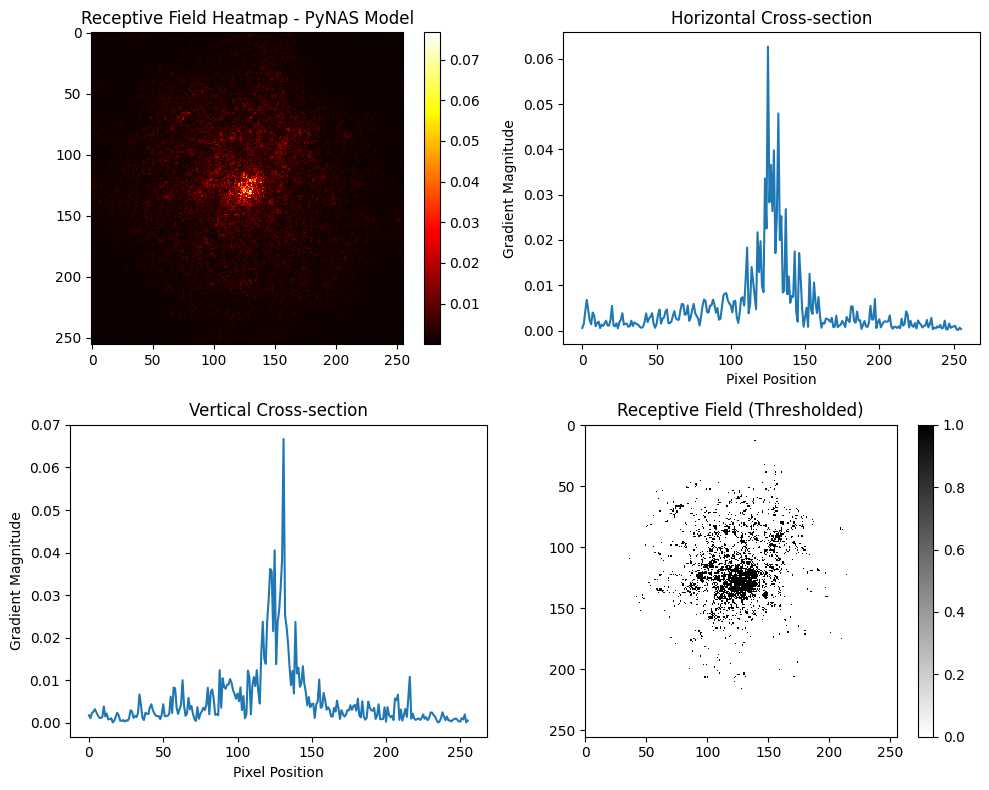

📊 Receptive Field Statistics for PyNAS Model:
   Active pixels: 2,415 / 65,536 (3.7%)
   Max gradient: 0.076713
   Mean gradient: 0.002102

--- ResNet18 U-Net ---


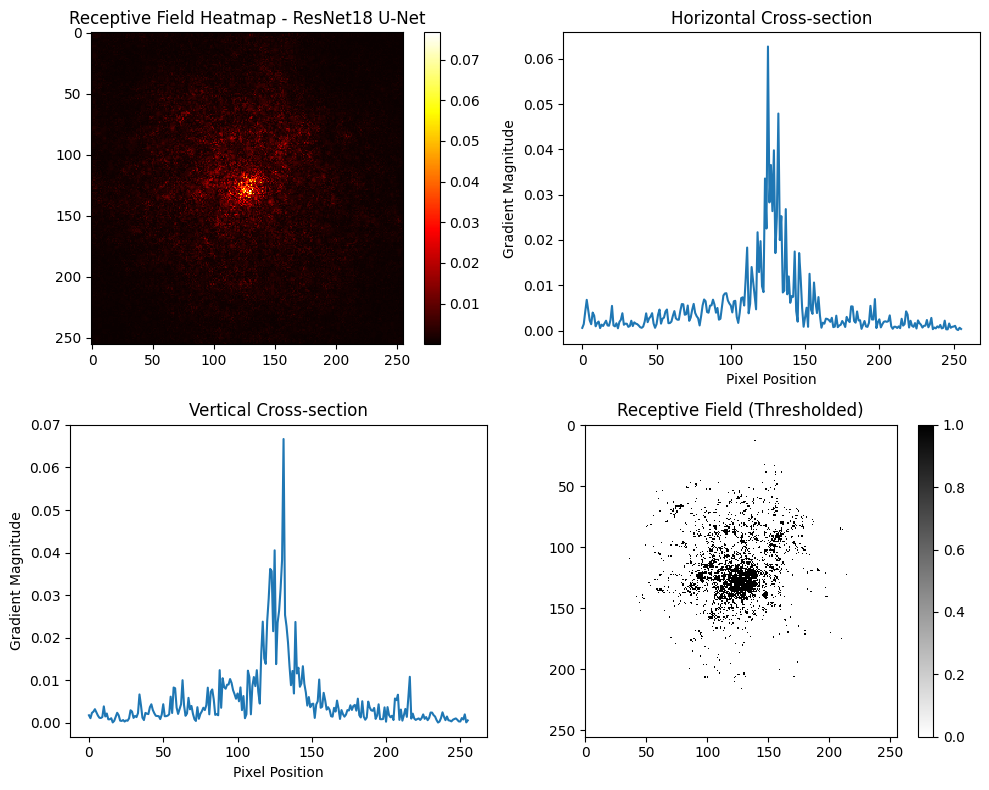

📊 Receptive Field Statistics for ResNet18 U-Net:
   Active pixels: 2,415 / 65,536 (3.7%)
   Max gradient: 0.076713
   Mean gradient: 0.002102


In [9]:
# Visualize receptive field pattern
import matplotlib.pyplot as plt

def plot_receptive_field(model, input_tensor, model_name):
    """Plot the receptive field heatmap"""
    rf_heatmap = visualize_receptive_field_pattern(model, input_tensor)
    
    if rf_heatmap is not None:
        plt.figure(figsize=(10, 8))
        
        # Plot the receptive field heatmap
        plt.subplot(2, 2, 1)
        plt.imshow(rf_heatmap.cpu().numpy(), cmap='hot', interpolation='nearest')
        plt.title(f'Receptive Field Heatmap - {model_name}')
        plt.colorbar()
        
        # Plot a cross-section through the center
        center_h, center_w = rf_heatmap.shape[0] // 2, rf_heatmap.shape[1] // 2
        
        plt.subplot(2, 2, 2)
        plt.plot(rf_heatmap[center_h, :].cpu().numpy())
        plt.title('Horizontal Cross-section')
        plt.xlabel('Pixel Position')
        plt.ylabel('Gradient Magnitude')
        
        plt.subplot(2, 2, 3)
        plt.plot(rf_heatmap[:, center_w].cpu().numpy())
        plt.title('Vertical Cross-section')
        plt.xlabel('Pixel Position')
        plt.ylabel('Gradient Magnitude')
        
        # Plot the thresholded receptive field
        plt.subplot(2, 2, 4)
        threshold = rf_heatmap.max() * 0.1  # 10% of max
        rf_binary = (rf_heatmap > threshold).float()
        plt.imshow(rf_binary.cpu().numpy(), cmap='binary', interpolation='nearest')
        plt.title('Receptive Field (Thresholded)')
        plt.colorbar()
        
        plt.tight_layout()
        plt.show()
        
        # Calculate and print statistics
        active_pixels = (rf_heatmap > threshold).sum().item()
        total_pixels = rf_heatmap.numel()
        
        print(f"📊 Receptive Field Statistics for {model_name}:")
        print(f"   Active pixels: {active_pixels:,} / {total_pixels:,} ({active_pixels/total_pixels*100:.1f}%)")
        print(f"   Max gradient: {rf_heatmap.max().item():.6f}")
        print(f"   Mean gradient: {rf_heatmap.mean().item():.6f}")
        
    else:
        print(f"❌ Could not generate receptive field visualization for {model_name}")

# Generate visualizations for selected models
print("🎨 RECEPTIVE FIELD VISUALIZATIONS")
print("=" * 80)

# Test on a couple of models to avoid too much output
selected_models = [
    ("PyNAS Model", model),
    ("ResNet18 U-Net", resnet_model)
]

for model_name, test_model in selected_models:
    print(f"\n--- {model_name} ---")
    plot_receptive_field(test_model, x.clone(), model_name)
    print("="*60)

🎨 RECEPTIVE FIELD HEATMAPS VISUALIZATION
🔥 GENERATING RECEPTIVE FIELD HEATMAPS
Generating heatmap for PyNAS Myriad...
  ✅ PyNAS Myriad: Active pixels 64/65,536 (0.1%)
Generating heatmap for PyNAS Orin...
  ✅ PyNAS Orin: Active pixels 192/65,536 (0.3%)
Generating heatmap for ResNet18 U-Net...
  ✅ ResNet18 U-Net: Active pixels 1,838/65,536 (2.8%)
Generating heatmap for EfficientNet-B0 U-Net...
  ✅ PyNAS Orin: Active pixels 192/65,536 (0.3%)
Generating heatmap for ResNet18 U-Net...
  ✅ ResNet18 U-Net: Active pixels 1,838/65,536 (2.8%)
Generating heatmap for EfficientNet-B0 U-Net...
  ✅ EfficientNet-B0 U-Net: Active pixels 585/65,536 (0.9%)
Generating heatmap for MobileOne-S0 U-Net...
  ✅ EfficientNet-B0 U-Net: Active pixels 585/65,536 (0.9%)
Generating heatmap for MobileOne-S0 U-Net...
  ✅ MobileOne-S0 U-Net: Active pixels 50/65,536 (0.1%)
  ✅ MobileOne-S0 U-Net: Active pixels 50/65,536 (0.1%)


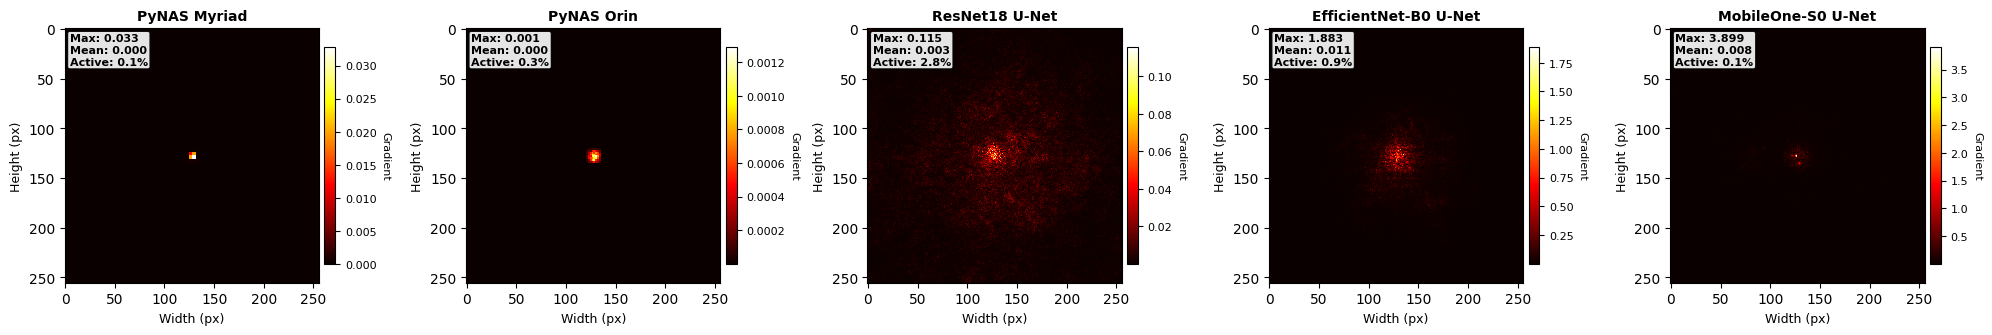


✅ Receptive field heatmaps generated!
Each heatmap shows:
  • Hot spots: Areas with highest gradient magnitude
  • Coverage: Percentage of input pixels in receptive field
  • Statistics: Max/mean gradient values and active pixel percentage


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define all models for analysis
all_models = {
    "PyNAS Myriad": model_myriad,
    "PyNAS Orin": model_orin,
    "ResNet18 U-Net": resnet_model,
    "EfficientNet-B0 U-Net": eff_model,
    "MobileOne-S0 U-Net": mobil_model
}

def plot_rf_heatmaps_only(all_models: dict, input_size: tuple = (256, 256)) -> None:
    """
    Create receptive field heatmaps for each model (heatmaps only).
    
    Args:
        all_models (dict): Dictionary of {model_name: model} pairs
        input_size (tuple): Input spatial dimensions (H, W)
    """
    
    num_models = len(all_models)
    
    # Create figure with single row layout
    fig, axes = plt.subplots(1, num_models, figsize=(4 * num_models, 4))
    
    # Ensure axes is always a list
    if num_models == 1:
        axes = [axes]
    
    print('🔥 GENERATING RECEPTIVE FIELD HEATMAPS')
    print('=' * 80)
    
    for idx, (model_name, model) in enumerate(all_models.items()):
        try:
            print(f'Generating heatmap for {model_name}...')
            
            # Create input tensor
            x = torch.randn(1, 7, *input_size)
            
            # Generate actual RF heatmap using gradient method
            rf_heatmap = visualize_receptive_field_pattern(model, x)
            
            if rf_heatmap is not None:
                # Plot the heatmap
                ax = axes[idx]
                im = ax.imshow(rf_heatmap.cpu().numpy(), cmap='hot', interpolation='nearest')
                
                # Set title and remove axes
                ax.set_title(f'{model_name}', fontsize=10, fontweight='bold')
                ax.set_xlabel('Width (px)', fontsize=9)
                ax.set_ylabel('Height (px)', fontsize=9)
                
                # Add colorbar
                cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
                cbar.set_label('Gradient', rotation=270, labelpad=10, fontsize=8)
                cbar.ax.tick_params(labelsize=8)
                
                # Calculate and display statistics
                max_val = rf_heatmap.max().item()
                mean_val = rf_heatmap.mean().item()
                threshold = max_val * 0.1
                active_pixels = (rf_heatmap > threshold).sum().item()
                total_pixels = rf_heatmap.numel()
                coverage = (active_pixels / total_pixels) * 100
                
                # Add text box with statistics
                stats_text = f'Max: {max_val:.3f}\nMean: {mean_val:.3f}\nActive: {coverage:.1f}%'
                ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                       verticalalignment='top', horizontalalignment='left',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9),
                       fontsize=8, fontweight='bold')
                
                print(f'  ✅ {model_name}: Active pixels {active_pixels:,}/{total_pixels:,} ({coverage:.1f}%)')
                
            else:
                # Handle failed heatmap generation
                ax = axes[idx]
                ax.text(0.5, 0.5, f'❌ Failed to generate\nheatmap for {model_name}', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, fontweight='bold', color='red')
                ax.set_title(f'{model_name}\n(Generation Failed)', fontsize=12, fontweight='bold')
                ax.set_xticks([])
                ax.set_yticks([])
                
                print(f'  ❌ {model_name}: Failed to generate heatmap')
                
        except Exception as e:
            # Handle errors
            ax = axes[idx]
            ax.text(0.5, 0.5, f'❌ Error:\n{str(e)[:50]}...', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=10, color='red')
            ax.set_title(f'{model_name}\n(Error)', fontsize=12, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            
            print(f'  ❌ {model_name}: Error - {e}')
            continue
    
    # Hide unused subplots - not needed for single row
    
    # Adjust layout
    plt.tight_layout(pad=1.0)
    
    # Add overall title
    # fig.suptitle('Receptive Field Heatmaps - Model Comparison', 
                # fontsize=16, fontweight='bold', y=0.98)
    
    plt.show()
    
    print('\n✅ Receptive field heatmaps generated!')
    print('Each heatmap shows:')
    print('  • Hot spots: Areas with highest gradient magnitude')
    print('  • Coverage: Percentage of input pixels in receptive field')
    print('  • Statistics: Max/mean gradient values and active pixel percentage')
    
    return fig

# Generate the RF heatmaps
print('🎨 RECEPTIVE FIELD HEATMAPS VISUALIZATION')
print('=' * 80)

fig = plot_rf_heatmaps_only(all_models, input_size=(256, 256))

In [11]:
# Test receptive field on a single model first
print("🧪 TESTING RECEPTIVE FIELD ANALYSIS")
print("=" * 80)

x = torch.randn(1, 7, 256, 256)

# Test on the PyNAS model first
print("Testing on PyNAS Model...")
print_receptive_field_analysis(model, x)

🧪 TESTING RECEPTIVE FIELD ANALYSIS
Testing on PyNAS Model...
RECEPTIVE FIELD ANALYSIS

--- THEORETICAL RECEPTIVE FIELD CALCULATION ---
Input Size: 256 x 256
Final Receptive Field: 7523 x 7523
Final Jump (stride): 256
RF as % of input: 2938.7%

Layer-by-layer Receptive Field Growth:
  encoder.conv1                  | Conv2d          | RF:    7 | Jump:   2 | Out: 128
  encoder.maxpool                | MaxPool2d       | RF:   11 | Jump:   4 | Out:  64
  encoder.layer1.0.conv1         | Conv2d          | RF:   19 | Jump:   4 | Out:  64
  encoder.layer1.0.conv2         | Conv2d          | RF:   27 | Jump:   4 | Out:  64
  encoder.layer1.1.conv1         | Conv2d          | RF:   35 | Jump:   4 | Out:  64
  encoder.layer1.1.conv2         | Conv2d          | RF:   43 | Jump:   4 | Out:  64
  encoder.layer2.0.conv1         | Conv2d          | RF:   51 | Jump:   8 | Out:  32
  encoder.layer2.0.conv2         | Conv2d          | RF:   67 | Jump:   8 | Out:  32
  encoder.layer2.0.downsample.0  | Co

In [12]:
%pip install tabulate

import pandas as pd

try:
    from tabulate import tabulate
    TABULATE_AVAILABLE = True
except ImportError:
    TABULATE_AVAILABLE = False
    print("Tabulate not available, using basic table formatting")

def create_rf_table(model: nn.Module, model_name: str, input_size: tuple = (256, 256)) -> pd.DataFrame:
    """
    Create a detailed receptive field table for a model.
    
    Args:
        model (nn.Module): The PyTorch model to analyze
        model_name (str): Name of the model
        input_size (tuple): Input spatial dimensions (H, W)
        
    Returns:
        pd.DataFrame: DataFrame containing RF analysis per layer
    """
    
    def get_layer_info_detailed(module, name):
        """Extract detailed layer parameters for receptive field calculation"""
        layer_info = {
            'layer_name': name,
            'layer_type': type(module).__name__,
            'kernel_size': None,
            'stride': None,
            'padding': None,
            'dilation': None,
            'groups': None,
            'parameters': sum(p.numel() for p in module.parameters())
        }
        
        if isinstance(module, nn.Conv2d):
            layer_info.update({
                'kernel_size': module.kernel_size[0] if isinstance(module.kernel_size, tuple) else module.kernel_size,
                'stride': module.stride[0] if isinstance(module.stride, tuple) else module.stride,
                'padding': module.padding[0] if isinstance(module.padding, tuple) else module.padding,
                'dilation': module.dilation[0] if isinstance(module.dilation, tuple) else module.dilation,
                'groups': module.groups,
                'in_channels': module.in_channels,
                'out_channels': module.out_channels
            })
        elif isinstance(module, (nn.MaxPool2d, nn.AvgPool2d)):
            kernel_size = module.kernel_size if isinstance(module.kernel_size, int) else module.kernel_size[0]
            stride = module.stride if module.stride is not None else kernel_size
            if isinstance(stride, (list, tuple)):
                stride = stride[0]
            padding = getattr(module, 'padding', 0)
            if isinstance(padding, (list, tuple)):
                padding = padding[0]
            
            layer_info.update({
                'kernel_size': kernel_size,
                'stride': stride,
                'padding': padding,
                'dilation': 1
            })
        elif isinstance(module, nn.AdaptiveAvgPool2d):
            layer_info.update({
                'kernel_size': 'adaptive',
                'output_size': module.output_size
            })
        
        return layer_info
    
    # Calculate RF progression
    rf_data = calculate_receptive_field(model, input_size)
    
    # Collect all layers with their details
    table_data = []
    layer_idx = 0
    
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.MaxPool2d, nn.AvgPool2d, nn.AdaptiveAvgPool2d)):
            layer_info = get_layer_info_detailed(module, name)
            
            # Find corresponding RF data
            rf_info = None
            if layer_idx < len(rf_data['layers_breakdown']):
                rf_info = rf_data['layers_breakdown'][layer_idx]
                layer_idx += 1
            
            row = {
                'Layer_Name': layer_info['layer_name'],
                'Layer_Type': layer_info['layer_type'],
                'Kernel_Size': layer_info['kernel_size'],
                'Stride': layer_info['stride'],
                'Padding': layer_info['padding'],
                'Dilation': layer_info.get('dilation', '-'),
                'Groups': layer_info.get('groups', '-'),
                'In_Channels': layer_info.get('in_channels', '-'),
                'Out_Channels': layer_info.get('out_channels', '-'),
                'Parameters': f"{layer_info['parameters']:,}" if layer_info['parameters'] > 0 else '0',
                'Receptive_Field': rf_info['receptive_field'] if rf_info else '-',
                'Jump_Stride': rf_info['jump'] if rf_info else '-',
                'Output_Size': rf_info['output_size'] if rf_info else '-'
            }
            
            table_data.append(row)
    
    df = pd.DataFrame(table_data)
    return df

def print_rf_comparison_table(models_dict: dict, input_size: tuple = (256, 256)) -> None:
    """
    Print comparison table of final RF values across models.
    
    Args:
        models_dict (dict): Dictionary of {model_name: model} pairs
        input_size (tuple): Input spatial dimensions
    """
    
    comparison_data = []
    
    for model_name, model in models_dict.items():
        try:
            # Calculate basic model statistics
            total_params = sum(p.numel() for p in model.parameters())
            trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            
            # Calculate RF
            rf_data = calculate_receptive_field(model, input_size)
            
            # Calculate MAC/GFLOPS if possible
            try:
                x_test = torch.randn(1, 7, *input_size)
                macs, params = profile(model, inputs=(x_test,), verbose=False)
                gflops = macs * 2 / 1e9
                macs_formatted = f"{macs/1e6:.1f}M"
                gflops_formatted = f"{gflops:.3f}"
            except:
                macs_formatted = "N/A"
                gflops_formatted = "N/A"
            
            rf_percentage = (rf_data["final_receptive_field"] / min(input_size)) * 100
            
            row = {
                'Model_Name': model_name,
                'Total_Parameters': f"{total_params:,}",
                'Trainable_Parameters': f"{trainable_params:,}",
                'MACs': macs_formatted,
                'GFLOPs': gflops_formatted,
                'Final_RF': rf_data["final_receptive_field"],
                'RF_Percentage': f"{rf_percentage:.1f}%",
                'Final_Jump': rf_data["final_jump"],
                'RF_Layers_Count': len(rf_data["layers_breakdown"])
            }
            
            comparison_data.append(row)
            
        except Exception as e:
            print(f"Error processing {model_name}: {e}")
            continue
    
    if comparison_data:
        df_comparison = pd.DataFrame(comparison_data)
        
        print("📊 MODEL COMPARISON TABLE")
        print("=" * 120)
        
        if TABULATE_AVAILABLE:
            print(tabulate(df_comparison, headers='keys', tablefmt='grid', showindex=False))
        else:
            # Fallback to pandas display
            pd.set_option('display.max_columns', None)
            pd.set_option('display.width', None)
            print(df_comparison.to_string(index=False))
            
        print("=" * 120)
        
        return df_comparison
    else:
        print("❌ No models could be processed for comparison")
        return None

def print_detailed_rf_tables(models_dict: dict, input_size: tuple = (256, 256)) -> dict:
    """
    Print detailed RF tables for each model.
    
    Args:
        models_dict (dict): Dictionary of {model_name: model} pairs
        input_size (tuple): Input spatial dimensions
        
    Returns:
        dict: Dictionary of {model_name: dataframe} pairs
    """
    
    all_tables = {}
    
    for model_name, model in models_dict.items():
        print(f"\n🏗️  DETAILED RECEPTIVE FIELD TABLE: {model_name}")
        print("=" * 140)
        
        try:
            df = create_rf_table(model, model_name, input_size)
            all_tables[model_name] = df
            
            # Print the table with nice formatting
            if TABULATE_AVAILABLE:
                print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))
            else:
                pd.set_option('display.max_columns', None)
                pd.set_option('display.width', None)
                print(df.to_string(index=False))
            
            # Print summary statistics
            max_rf = df['Receptive_Field'].replace('-', 0).astype(int).max()
            total_layers = len(df)
            conv_layers = len(df[df['Layer_Type'] == 'Conv2d'])
            pool_layers = len(df[df['Layer_Type'].str.contains('Pool', na=False)])
            
            print(f"\n📈 Summary for {model_name}:")
            print(f"   • Total RF layers: {total_layers}")
            print(f"   • Conv2d layers: {conv_layers}")
            print(f"   • Pooling layers: {pool_layers}")
            print(f"   • Maximum RF: {max_rf}")
            print(f"   • RF coverage: {(max_rf / min(input_size)) * 100:.1f}% of input")
            
        except Exception as e:
            print(f"❌ Error creating table for {model_name}: {e}")
            continue
    
    return all_tables

# Define all models for analysis
all_models = {
    "PyNAS Myriad": model_myriad,
    "PyNAS Orin": model_orin,
    "ResNet18 U-Net": resnet_model,
    "EfficientNet-B0 U-Net": eff_model,
    "MobileOne-S0 U-Net": mobil_model
}

# Create comprehensive RF analysis
print("🎯 COMPREHENSIVE RECEPTIVE FIELD ANALYSIS")
print("=" * 140)

# First, create comparison table
comparison_df = print_rf_comparison_table(all_models, input_size=(256, 256))


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
🎯 COMPREHENSIVE RECEPTIVE FIELD ANALYSIS
Note: you may need to restart the kernel to use updated packages.
🎯 COMPREHENSIVE RECEPTIVE FIELD ANALYSIS
📊 MODEL COMPARISON TABLE
+-----------------------+--------------------+------------------------+---------+----------+------------+-----------------+--------------+-------------------+
| Model_Name            | Total_Parameters   | Trainable_Parameters   | MACs    | GFLOPs   |   Final_RF | RF_Percentage   |   Final_Jump |   RF_Layers_Count |
+=======================+====================+========================+=========+==========+============+=================+==============+===================+
| PyNAS Myriad          | 865                | 865            

In [13]:
# Generate detailed RF tables for each model
print("\n\n🔬 DETAILED LAYER-BY-LAYER RECEPTIVE FIELD ANALYSIS")
print("=" * 140)

detailed_tables = print_detailed_rf_tables(all_models, input_size=(256, 256))

# Save tables to files if needed
save_tables = False  # Set to True if you want to save CSV files

if save_tables and detailed_tables:
    print("\n💾 SAVING TABLES TO CSV FILES")
    print("=" * 60)
    
    for model_name, df in detailed_tables.items():
        filename = f"rf_analysis_{model_name.replace(' ', '_').replace('-', '_').lower()}.csv"
        df.to_csv(filename, index=False)
        print(f"Saved: {filename}")
    
    # Also save comparison table
    if 'comparison_df' in locals():
        comparison_df.to_csv("rf_comparison_all_models.csv", index=False)
        print("Saved: rf_comparison_all_models.csv")

print("\n✅ RECEPTIVE FIELD TABLE ANALYSIS COMPLETE!")
print("=" * 60)



🔬 DETAILED LAYER-BY-LAYER RECEPTIVE FIELD ANALYSIS

🏗️  DETAILED RECEPTIVE FIELD TABLE: PyNAS Myriad
+---------------------+--------------+---------------+----------+-----------+------------+----------+---------------+----------------+--------------+-------------------+---------------+---------------+
| Layer_Name          | Layer_Type   |   Kernel_Size |   Stride |   Padding |   Dilation |   Groups | In_Channels   | Out_Channels   |   Parameters |   Receptive_Field |   Jump_Stride |   Output_Size |
+=====================+==============+===============+==========+===========+============+==========+===============+================+==============+===================+===============+===============+
| encoder.1.0         | AvgPool2d    |             2 |        2 |         0 |          1 |      nan | -             | -              |            0 |                 2 |             2 |           128 |
+---------------------+--------------+---------------+----------+-----------+------------

In [14]:
# Create a focused summary of key RF metrics
def create_rf_summary_table(models_dict: dict) -> pd.DataFrame:
    """Create a focused summary table with key RF metrics"""
    
    summary_data = []
    
    for model_name, model in models_dict.items():
        try:
            rf_data = calculate_receptive_field(model, (256, 256))
            total_params = sum(p.numel() for p in model.parameters())
            
            # Calculate efficiency metrics
            rf_per_param = rf_data["final_receptive_field"] / (total_params / 1000)  # RF per 1K params
            rf_coverage = (rf_data["final_receptive_field"] / 256) * 100
            
            # Count layer types
            conv_count = 0
            pool_count = 0
            for name, module in model.named_modules():
                if isinstance(module, nn.Conv2d):
                    conv_count += 1
                elif isinstance(module, (nn.MaxPool2d, nn.AvgPool2d)):
                    pool_count += 1
            
            summary_data.append({
                'Model': model_name,
                'Final_RF': rf_data["final_receptive_field"],
                'RF_Coverage_%': f"{rf_coverage:.1f}%",
                'Final_Jump': rf_data["final_jump"],
                'Total_Params_K': f"{total_params/1000:.1f}K",
                'RF_per_1K_Params': f"{rf_per_param:.2f}",
                'Conv_Layers': conv_count,
                'Pool_Layers': pool_count,
                'Total_RF_Layers': len(rf_data["layers_breakdown"])
            })
            
        except Exception as e:
            print(f"Error processing {model_name}: {e}")
            continue
    
    return pd.DataFrame(summary_data)

print("\n\n🎯 KEY RECEPTIVE FIELD METRICS SUMMARY")
print("=" * 100)

rf_summary = create_rf_summary_table(all_models)

if TABULATE_AVAILABLE:
    print(tabulate(rf_summary, headers='keys', tablefmt='fancy_grid', showindex=False))
else:
    print(rf_summary.to_string(index=False))

print("\n📊 RECEPTIVE FIELD ANALYSIS INSIGHTS:")
print("=" * 60)

# Find best and worst performers
if len(rf_summary) > 0:
    best_coverage = rf_summary.loc[rf_summary['RF_Coverage_%'].str.rstrip('%').astype(float).idxmax()]
    worst_coverage = rf_summary.loc[rf_summary['RF_Coverage_%'].str.rstrip('%').astype(float).idxmin()]
    
    best_efficiency = rf_summary.loc[rf_summary['RF_per_1K_Params'].astype(float).idxmax()]
    worst_efficiency = rf_summary.loc[rf_summary['RF_per_1K_Params'].astype(float).idxmin()]
    
    print(f"🏆 Best RF Coverage: {best_coverage['Model']} ({best_coverage['RF_Coverage_%']})")
    print(f"📉 Lowest RF Coverage: {worst_coverage['Model']} ({worst_coverage['RF_Coverage_%']})")
    print(f"⚡ Most RF Efficient: {best_efficiency['Model']} (RF per 1K params: {best_efficiency['RF_per_1K_Params']})")
    print(f"🐌 Least RF Efficient: {worst_efficiency['Model']} (RF per 1K params: {worst_efficiency['RF_per_1K_Params']})")
    
    # Architecture insights
    avg_rf = rf_summary['Final_RF'].mean()
    avg_params = rf_summary['Total_Params_K'].str.rstrip('K').astype(float).mean()
    
    print(f"\n📈 Average Metrics Across All Models:")
    print(f"   • Average Final RF: {avg_rf:.0f} pixels")
    print(f"   • Average Parameters: {avg_params:.0f}K")
    print(f"   • Average RF Coverage: {(avg_rf/256)*100:.1f}% of input")

print("\n✅ RF TABLE ANALYSIS COMPLETE!")
print("Use the detailed tables above to:")
print("• Compare layer-by-layer RF growth")
print("• Identify bottleneck layers")
print("• Optimize architecture efficiency")
print("• Select models based on RF requirements")
print("=" * 60)



🎯 KEY RECEPTIVE FIELD METRICS SUMMARY
╒═══════════════════════╤════════════╤═════════════════╤══════════════╤══════════════════╤════════════════════╤═══════════════╤═══════════════╤═══════════════════╕
│ Model                 │   Final_RF │ RF_Coverage_%   │   Final_Jump │ Total_Params_K   │   RF_per_1K_Params │   Conv_Layers │   Pool_Layers │   Total_RF_Layers │
╞═══════════════════════╪════════════╪═════════════════╪══════════════╪══════════════════╪════════════════════╪═══════════════╪═══════════════╪═══════════════════╡
│ PyNAS Myriad          │         16 │ 6.2%            │            8 │ 0.9K             │              18.5  │             4 │             3 │                 7 │
├───────────────────────┼────────────┼─────────────────┼──────────────┼──────────────────┼────────────────────┼───────────────┼───────────────┼───────────────────┤
│ PyNAS Orin            │       6148 │ 2401.6%         │         1024 │ 34.2K            │             179.81 │             8 │             

In [15]:
import torch.nn as nn

def count_rf_layers(model: nn.Module):
    rf_layers = []
    for name, m in model.named_modules():
        if isinstance(m, (nn.Conv2d, nn.MaxPool2d, nn.AvgPool2d, nn.ConvTranspose2d, nn.Upsample, nn.Dropout)):
            rf_layers.append(name)
    # print(f"Total RF-affecting layers: {len(rf_layers)}")
    # for n in rf_layers:
    #     print("  ", n)
    return rf_layers


for model in all_models:
    l = count_rf_layers(all_models[model])
    print(f"\nModel: {model}", f"has {len(l)} RF-affecting layers")




Model: PyNAS Myriad has 10 RF-affecting layers

Model: PyNAS Orin has 14 RF-affecting layers

Model: ResNet18 U-Net has 32 RF-affecting layers

Model: EfficientNet-B0 U-Net has 93 RF-affecting layers

Model: MobileOne-S0 U-Net has 202 RF-affecting layers


In [16]:
%pip install torchsummary
from torchsummary import summary

for model in all_models:
    l = count_rf_layers(all_models[model])
    summary(model, input_size=(7, 224, 224))
    print(f"\nModel: {model}", f"has {len(l)} RF-affecting layers")


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


AttributeError: 'str' object has no attribute 'apply'